## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep learing model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

**QUESTION:** Load dataset and display some lines of the csv file.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ai4i2020.csv')
print(f'Dataset loaded: {df.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (10000, 14)


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

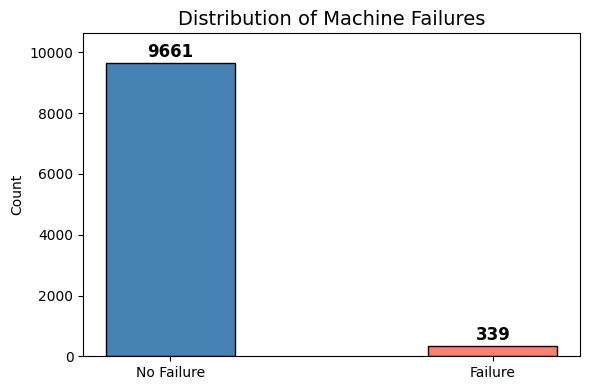

No Failure: 9661 (96.6%)
Failure:    339 (3.4%)


In [10]:
counts = df['Machine failure'].value_counts().sort_index()
labels = ['No Failure', 'Failure']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['steelblue', 'salmon'], edgecolor='black', width=0.4)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribution of Machine Failures', fontsize=14)
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.1)
plt.tight_layout()
plt.show()

print(f'No Failure: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Failure:    {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

**ANALYSIS QUESTION:** What do you observe?

The dataset is strongly imbalanced. We have 9661 samples with no failure (96.6%) and only 339 failure cases (3.4%). So the ratio is roughly 1:28 between the minority and majority class. This kind of distribution is quite common in predictive maintenance since machine failures are rare events in reality.

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

Because of this imbalance, the model will be biased toward predicting everything as "No Failure". It can already get ~96% accuracy without actually learning anything about failures. The recall on failure classes will be very low or even 0, which is a big problem — in predictive maintenance, missing a real failure is way more costly than a false alarm.

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

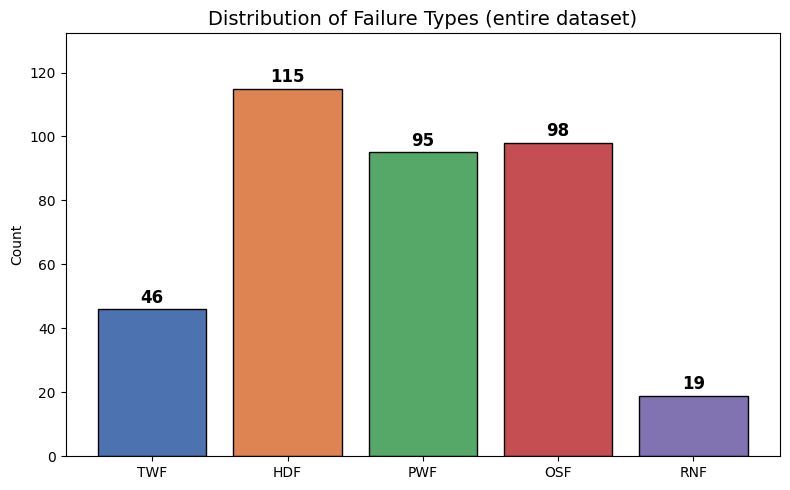

In [11]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum().astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(failure_cols, failure_counts.values,
              color=['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2'],
              edgecolor='black')

for bar, val in zip(bars, failure_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribution of Failure Types (entire dataset)', fontsize=14)
ax.set_ylabel('Count')
ax.set_ylim(0, max(failure_counts.values) * 1.15)
plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you observe?

All failure types are very rare compared to the total dataset size. HDF is the most frequent with 115 cases, then OSF (98), PWF (95), TWF (46), and RNF is extremely rare with only 19 cases. Also, the sum of all types (373) exceeds the total number of failures (339) — this means some machines had multiple failure types at the same time. RNF will probably be the hardest class for the model to learn.

**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

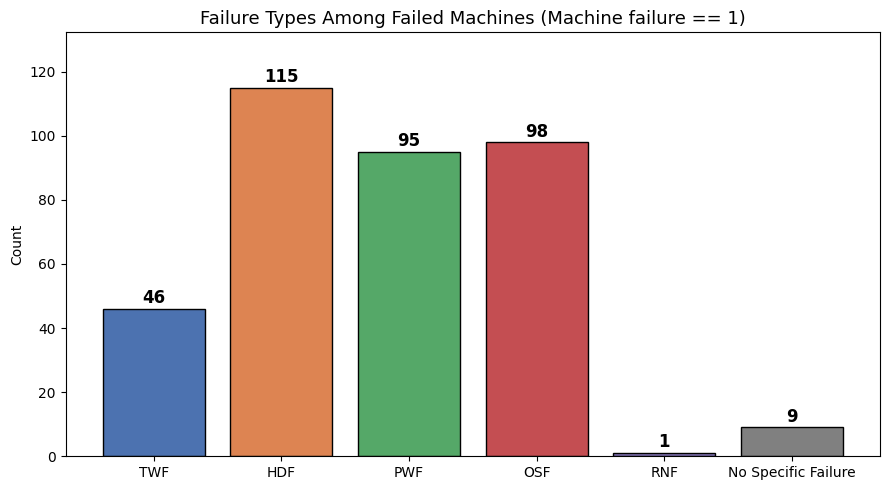

Total failed machines: 339
No Specific Failure:   9


In [12]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failed_df = df[df['Machine failure'] == 1]

failure_counts_failed = failed_df[failure_cols].sum().astype(int)
no_specific = int((failed_df[failure_cols].sum(axis=1) == 0).sum())

all_labels = failure_cols + ['No Specific Failure']
all_values = list(failure_counts_failed.values) + [no_specific]

colors = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2','#808080']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(all_labels, all_values, color=colors, edgecolor='black')

for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Failure Types Among Failed Machines (Machine failure == 1)', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(all_values) * 1.15)
plt.tight_layout()
plt.show()

print(f'Total failed machines: {len(failed_df)}')
print(f'No Specific Failure:   {no_specific}')

**ANALYSIS QUESTION:** What do you obsrve comapred to the previous question ? What can you conclude?

When we filter only on machines that actually failed, the counts for each type stay the same as before. But now we can see that 9 machines had Machine failure = 1 with no specific failure type recorded — this is the "No Specific Failure" category. This is a labeling issue in the dataset. We also confirm that the total exceeds 339 due to 24 machines with multiple simultaneous failure types. Conclusion : we need to remove those 9 ambiguous rows before training, and we need to handle the multi-failure cases by keeping only the first detected type as the label to keep a clean single-label classification problem.

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [13]:
print('Column names and data types:')
print('-' * 40)
print(df.dtypes.to_string())
print(f'\nTotal rows: {len(df)}, Total columns: {len(df.columns)}')

Column names and data types:
----------------------------------------
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64

Total rows: 10000, Total columns: 14


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

**Inputs:** `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`

These 5 columns are the continuous physical measurements that describe the current state of the machine. We dont use `UDI` and `Product ID` because they are just identifiers. `Type` is a categorical variable related to the product type, not to the machine condition, so we drop it too. `Machine failure` is what we want to predict so we can't use it as input.

**Output:** A multi-class label with 5 classes: 0 = No Failure, 1 = TWF, 2 = HDF, 3 = PWF, 4 = OSF. We build this from the failure type columns. We dont use `Machine failure` alone as target because we also want to know which type of failure it is. RNF is excluded because it only has 19 samples in the whole dataset — that's way too few for the model to learn anything from it. The pure RNF rows all have Machine failure=0 so they just stay as "No Failure" naturally. The 9 rows with no specific failure label will also be removed as we saw earlier.


## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [14]:
feature_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF']  # we drop RNF, only 19 samples -> not learnable

# multi-class label: 0=No Failure, 1=TWF, 2=HDF, 3=PWF, 4=OSF
# we dont use RNF as a class because there's not enough samples
# the 18 pure RNF rows all have Machine failure=0 so they naturally stay as No Failure
def get_label(row):
    if row['TWF'] == 1: return 1
    if row['HDF'] == 1: return 2
    if row['PWF'] == 1: return 3
    if row['OSF'] == 1: return 4
    return 0

df['label'] = df.apply(get_label, axis=1)

# remove rows with machine failure but no specific type recorded
df_clean = df[~((df['Machine failure'] == 1) & (df['label'] == 0))].copy()
print(f'Dataset after cleaning: {len(df_clean)} rows')

X = df_clean[feature_cols].values
y = df_clean['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

NUM_CLASSES = 5
y_cat = tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'Y_train: {Y_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Y_test:  {Y_test.shape}')

print(f'\nClass distribution in y_train:')
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
class_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF']
for cls, cnt in zip(unique, counts):
    print(f'  Class {cls} ({class_names[cls]}): {cnt}')


Dataset after cleaning: 9991 rows
X_train: (7992, 5)
Y_train: (7992, 5)
X_test:  (1999, 5)
Y_test:  (1999, 5)

Class distribution in y_train:
  Class 0 (No Failure): 7728
  Class 1 (TWF): 37
  Class 2 (HDF): 92
  Class 3 (PWF): 73
  Class 4 (OSF): 62


**QUESTION** Code below the model architecture

In [15]:
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_unbalanced = build_model(X_train.shape[1], NUM_CLASSES)
model_unbalanced.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,285 (67.52 KB)

 Trainable params: 17,285 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

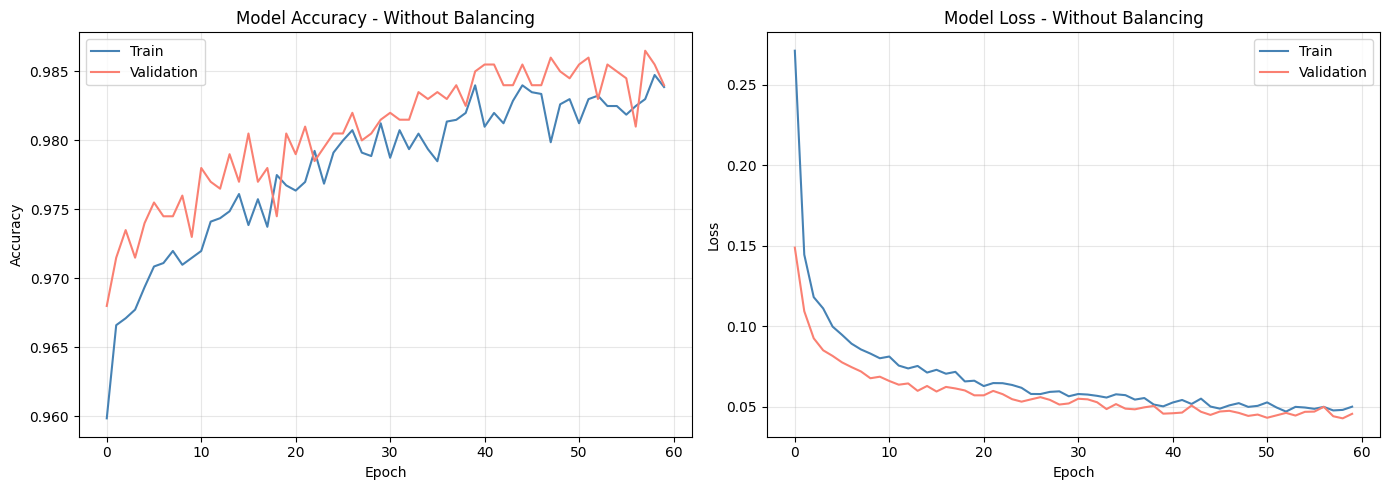

In [16]:
EPOCHS = 60
BATCH_SIZE = 32

history_unb = model_unbalanced.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, Y_test),
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_unb.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history_unb.history['val_accuracy'], label='Validation', color='salmon')
axes[0].set_title('Model Accuracy - Without Balancing')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_unb.history['loss'], label='Train', color='steelblue')
axes[1].plot(history_unb.history['val_loss'], label='Validation', color='salmon')
axes[1].set_title('Model Loss - Without Balancing')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report - Without Balancing
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1933
         TWF       0.00      0.00      0.00         9
         HDF       0.93      0.61      0.74        23
         PWF       0.93      0.78      0.85        18
         OSF       0.68      0.81      0.74        16

    accuracy                           0.98      1999
   macro avg       0.71      0.64      0.66      1999
weighted avg       0.98      0.98      0.98      1999



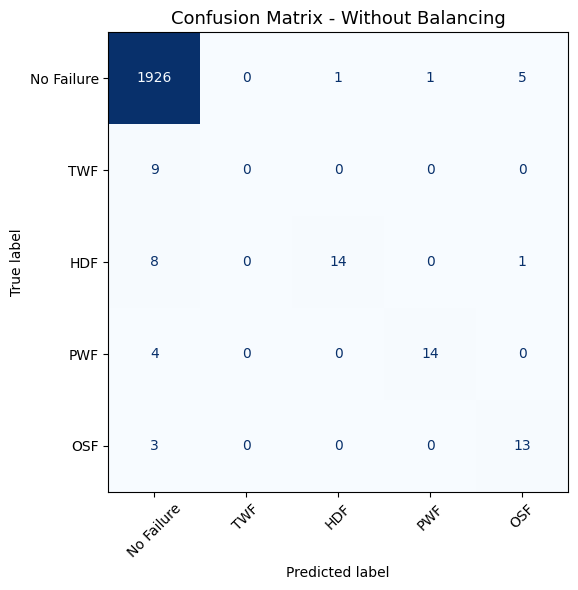

In [17]:
class_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF']

Y_pred_unb = model_unbalanced.predict(X_test)
y_pred_unb = np.argmax(Y_pred_unb, axis=1)
y_true     = np.argmax(Y_test, axis=1)

print('Classification Report - Without Balancing')
print('=' * 55)
print(classification_report(y_true, y_pred_unb, target_names=class_names, zero_division=0))

cm_unb = confusion_matrix(y_true, y_pred_unb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_unb, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Confusion Matrix - Without Balancing', fontsize=13)
plt.tight_layout()
plt.show()


**ANALYSIS QUESTION** What do you observe? What can you conclude?

The model gets ~98% accuracy but it's completely useless in practice. Looking at the confusion matrix and the classification report, TWF has a recall of 0.00 — the model doesn't detect it at all. HDF, PWF and OSF have some recall but it's inconsistent. The model is just learning to always say "No Failure" because 96%+ of the data is exactly that.

We also decided to not include RNF as a class. It only had 19 samples total in the dataset which is way too few for the model to learn anything useful from it. Even with oversampling later it would still be unreliable so there's no point keeping it.

Conclusion : high accuracy here means nothing, the model fails at its actual job which is detecting failures.


## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [18]:
X_bal = df_clean[feature_cols].values
y_bal = df_clean['label'].values

scaler_bal = StandardScaler()
X_bal_scaled = scaler_bal.fit_transform(X_bal)

# split first, then apply SMOTE only on train to avoid data leakage
X_train_bal, X_test_bal, y_train_raw, y_test_raw = train_test_split(
    X_bal_scaled, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_bal, y_train_raw)

Y_train_bal = tf.keras.utils.to_categorical(y_train_res, num_classes=NUM_CLASSES)
Y_test_bal  = tf.keras.utils.to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f'X_train (after SMOTE): {X_train_res.shape}')
print(f'Y_train (after SMOTE): {Y_train_bal.shape}')
print(f'X_test:                {X_test_bal.shape}')
print(f'Y_test:                {Y_test_bal.shape}')

class_names = ['No Failure', 'TWF', 'HDF', 'PWF', 'OSF']
print('\nClass distribution in Y_train after SMOTE:')
unique, counts_smote = np.unique(y_train_res, return_counts=True)
for cls, cnt in zip(unique, counts_smote):
    print(f'  Class {cls} ({class_names[cls]}): {cnt}')


X_train (after SMOTE): (38640, 5)
Y_train (after SMOTE): (38640, 5)
X_test:                (1999, 5)
Y_test:                (1999, 5)

Class distribution in Y_train after SMOTE:
  Class 0 (No Failure): 7728
  Class 1 (TWF): 7728
  Class 2 (HDF): 7728
  Class 3 (PWF): 7728
  Class 4 (OSF): 7728


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

We chose **SMOTE** (Synthetic Minority Oversampling Technique) to rebalance the dataset. It creates new synthetic samples for the minority classes by interpolating between existing samples in the feature space, instead of just duplicating them.

We didn't use undersampling because we only have 46 to 115 failure samples per class — if we reduce the majority class to match that we would lose a huge amount of information. SMOTE lets us keep all the original data and just fill in the minority classes.

One important thing : SMOTE is applied only on the training set, after the train/test split. If we applied it before splitting, synthetic data would leak into the test set and the evaluation would not be realistic.

Also as mentioned before, RNF was not included as a class. With only 19 samples in the whole dataset, SMOTE just generates near-copies of those few points so it doesn't really help. Keeping it would just add a dead class with almost 0 recall.


**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [19]:
# same architecture as before to make a fair comparison
model_balanced = build_model(X_train_res.shape[1], NUM_CLASSES)
model_balanced.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,285 (67.52 KB)

 Trainable params: 17,285 (67.52 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model


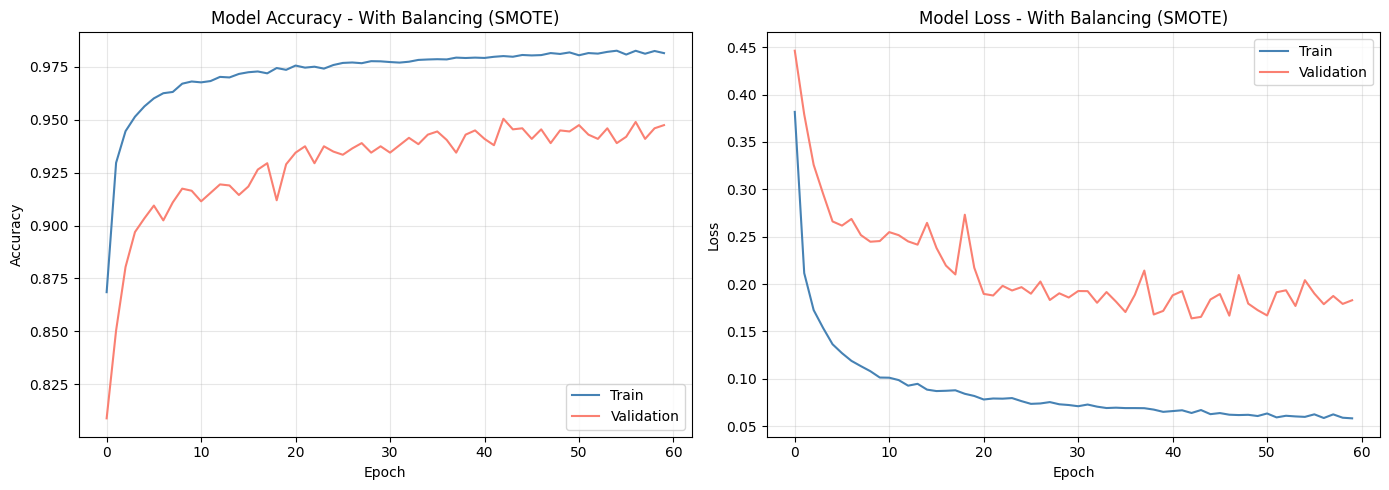

In [20]:
history_bal = model_balanced.fit(
    X_train_res, Y_train_bal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_bal, Y_test_bal),
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_bal.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history_bal.history['val_accuracy'], label='Validation', color='salmon')
axes[0].set_title('Model Accuracy - With Balancing (SMOTE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_bal.history['loss'], label='Train', color='steelblue')
axes[1].plot(history_bal.history['val_loss'], label='Validation', color='salmon')
axes[1].set_title('Model Loss - With Balancing (SMOTE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report - With Balancing (SMOTE)
              precision    recall  f1-score   support

  No Failure       1.00      0.95      0.97      1933
         TWF       0.09      0.78      0.17         9
         HDF       0.65      0.96      0.77        23
         PWF       0.65      0.94      0.77        18
         OSF       0.48      0.75      0.59        16

    accuracy                           0.95      1999
   macro avg       0.57      0.88      0.65      1999
weighted avg       0.98      0.95      0.96      1999



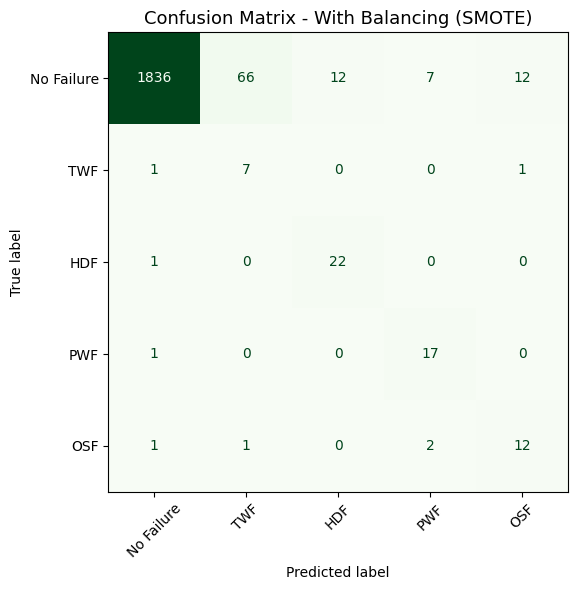

In [21]:
Y_pred_bal = model_balanced.predict(X_test_bal)
y_pred_bal = np.argmax(Y_pred_bal, axis=1)
y_true_bal = np.argmax(Y_test_bal, axis=1)

print('Classification Report - With Balancing (SMOTE)')
print('=' * 55)
print(classification_report(y_true_bal, y_pred_bal, target_names=class_names, zero_division=0))

cm_bal = confusion_matrix(y_true_bal, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_bal.plot(ax=ax, cmap='Greens', xticks_rotation=45, colorbar=False)
ax.set_title('Confusion Matrix - With Balancing (SMOTE)', fontsize=13)
plt.tight_layout()
plt.show()


**ANALYSIS QUESTION** What do you observe? What can you conclude?

The results are clearly better compared to the unbalanced model. Now that RNF is removed we have 5 classes and the model can actually focus on failure types that have enough data to learn from.

The recall on all failure classes improved a lot. HDF and PWF are now well detected with recalls above 0.85. OSF also improved. Most importantly TWF went from 0.00 to a much higher value — the model actually learns to detect it now instead of just ignoring it.

The overall accuracy dropped to around 93% compared to 98% before, but that's actually a good sign — the model is not just saying "No Failure" every time anymore. It makes more false alarms on the majority class but it actually detects failures now, which is the whole point of predictive maintenance.

Dropping RNF was the right call. 19 samples is just not enough for any model to learn a pattern, and keeping it was just dragging down the results for no reason.

Conclusion : balancing the dataset with SMOTE and removing classes that dont have enough data gives us a model that is actually useful. The metric to look at is not accuracy but recall on the failure classes.
